# Imports

In [2]:
from IPython.display import Image, display, SVG, HTML
from typing import Dict, List, Tuple, Generator, Optional, Any, Literal
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
import concurrent.futures
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde
import gc

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.patches import Rectangle, FancyArrowPatch

import seaborn as sns
import pandas as pd
import numpy as np
import os
import re
import time
import datetime
import multiprocessing

from tqdm import tqdm
import otf2
import hatchet as ht
import thicket as tt
from collections import defaultdict


TEXLIVE_BIN_DIR = "/sw/frontier/spack-envs/base/opt/linux-sles15-x86_64/gcc-7.5.0/texlive-20220321-m56xupci4mc7hwbmnqy4oovch5pc7rrd/bin/x86_64-linux"
if TEXLIVE_BIN_DIR not in os.environ['PATH']:
    os.environ['PATH'] += os.pathsep + TEXLIVE_BIN_DIR
    print(f"Successfully added TexLive directory to PATH.")
else:
    print("TexLive directory was already in PATH.")
    
plt.rcParams['text.usetex'] = True

FONT_SIZE = 18
plt.rcParams.update({
    'font.size': FONT_SIZE,             # Controls default text sizes
    'axes.labelsize': FONT_SIZE * 0.95,        # Font size of the x and y labels
    'xtick.labelsize': FONT_SIZE * 0.9, # Font size for x-axis tick labels
    'ytick.labelsize': FONT_SIZE * 0.9, # Font size for y-axis tick labels
    'legend.fontsize': FONT_SIZE * 0.5,       # Font size of the legend
    'figure.titlesize': FONT_SIZE * 1.5 # Font size for the figure title
})

Successfully added TexLive directory to PATH.


In [3]:
# Track how long the notebook takes to run
NOTEBOOK_START_TIME = time.time()
print(f"Notebook started at {NOTEBOOK_START_TIME} ({datetime.datetime.fromtimestamp(NOTEBOOK_START_TIME)})")

Notebook started at 1766156451.6208098 (2025-12-19 10:00:51.620810)


# Preamble

### Define The Name of the Cluster & Trace Paths

Define the name of the cluster and the paths to the trace files.
This is needed to parse the trace directory paths correctly as generated by the master run script.

In [4]:
# CLUSTER_NAME = "parrypeak"

STEP_VECTOR_SIZE = 134217728 # 2^27

# ROOT_TRACE_DIR = "/lustre/orion/csc688/world-shared/scorep-amd/runs/32-node-run-1"
# ROOT_TRACE_DIR = '/lustre/orion/csc688/world-shared/results-mi300a-organized'

### Define Which Ranks Run on Each Node

Define the topology of the runs. This is needed to attribute energy consumption correctly. Metrics are gathered at the node level, so we
need to know which node each rank ran on to get the metrics associated with that node + rank.

In [5]:
ACTIVE_PERIODS_MS = [1, 2, 5, 20, 50, 100, 200, 400, 1000]
IDLE_PERIODS_MS = ACTIVE_PERIODS_MS

DOUBLE_GCD_NODE_RANKS = {'node0': ['MPI Rank 0', 'MPI Rank 1', 'MPI Rank 2', 'MPI Rank 3', 'MPI Rank 4', 'MPI Rank 5', 'MPI Rank 6', 'MPI Rank 7']}
SINGLE_GCD_NODE_RANKS = {'node0': ['MPI Rank 0', 'MPI Rank 1', 'MPI Rank 2', 'MPI Rank 3']}
APU_NODE_RANKS = {'node0': ['MPI Rank 0', 'MPI Rank 1', 'MPI Rank 2', 'MPI Rank 3']}

### Define The Metrics to Attribute to Each Rank

This defines which MPI rank is on which GCD (frontier) or APU (el capitan). Two ranks drawing from the same GPU (each GPU has 2 GCDs) will have their energy consumption estimated independently based on their exclusive runtime.

In [6]:
DOUBLE_GCD_RANKS_TO_METRICS = {
	'MPI Rank 0': ['A2rocm_smi:::energy_count:device=0'],
	'MPI Rank 1': ['A2rocm_smi:::energy_count:device=1'],
	'MPI Rank 2': ['A2rocm_smi:::energy_count:device=2'],
	'MPI Rank 3': ['A2rocm_smi:::energy_count:device=3'],
}

SINGLE_GCD_RANKS_TO_METRICS = {
    'MPI Rank 0': ['A2rocm_smi:::energy_count:device=0'],
    'MPI Rank 1': ['A2rocm_smi:::energy_count:device=1'],
    'MPI Rank 2': ['A2rocm_smi:::energy_count:device=2'],
    'MPI Rank 3': ['A2rocm_smi:::energy_count:device=3']
}

APU_RANKS_TO_METRICS = {
    'MPI Rank 0': ['A2rocm_smi:::energy_count:device=0'],
    'MPI Rank 1': ['A2rocm_smi:::energy_count:device=1'],
    'MPI Rank 2': ['A2rocm_smi:::energy_count:device=2'],
    'MPI Rank 3': ['A2rocm_smi:::energy_count:device=3']
}

### Define Which Metrics to Track in the Traces

This defines the metrics we're going to pay attention to when parsing the traces.
All metrics that are used above must be included here.

In [7]:
METRICS_TO_TRACK = [
    'A2rocm_smi:::energy_count:device=0',
    'A2rocm_smi:::energy_count:device=2',
    'A2rocm_smi:::energy_count:device=4',
    'A2rocm_smi:::energy_count:device=6',
    
    'A2coretemp:::craypm:accel0_energy',
    'A2coretemp:::craypm:accel1_energy',
    'A2coretemp:::craypm:accel2_energy',
    'A2coretemp:::craypm:accel3_energy',
    
    'A2coretemp:::craypm:accel0_power',
    'A2coretemp:::craypm:accel1_power',
    'A2coretemp:::craypm:accel2_power',
    'A2coretemp:::craypm:accel3_power'
]

In [8]:
def calculate_steps_from_periods(time_active, time_sleep, time_desired=15000):
    # local time_active=$1
    # local time_sleep=$2
    # local nsteps=$((15000 / (time_active + time_sleep))) # Target ~15s total time
    return math.floor((time_desired + 1) / (time_active + time_sleep))  # Target ~15s total time

In [9]:
def get_trace_paths_for_step_variant(root_trace_dir: str, cluster_name: str, ranks: Optional[int]=None, convert=True) -> Dict[Tuple[int, int], List[str]]:
    if convert:
        for dirpath, dnames, filenames in tqdm(os.walk(root_trace_dir)):
            trace = os.path.join(dirpath, 'traces.otf2')
            if not os.path.exists(trace):
                continue
            if os.path.exists(os.path.join(dirpath, 'MPI Rank 0_Master_thread_callgraph.csv')) and os.path.exists(os.path.join(dirpath, 'MPI Rank 0_metrics.csv')):
                continue
            else:
                print(f"Converting trace to CSV: {trace}")
            cmd = f'source /lustre/orion/csc688/world-shared/scorep-amd/setup-env.sh > /dev/null 2>&1 && ./trace_to_csv_parallel --trace={trace} --metrics="{",".join(METRICS_TO_TRACK)}" --outputDir={dirpath} > /dev/null 2>&1'
            if os.system(cmd):
                print(f'Error running command: {cmd}')
                print(f"Error converting trace: {trace}")
        
    result = {}
    # Instead, just iterate through all the traces and add them based on their time active and idle
    for d in os.listdir(f"{root_trace_dir}/"):
        # Get the time_active and time_idle from the directory name
        pattern = rf"step_function-{'r' + str(ranks) + '-' if ranks else ''}--vector_size_{STEP_VECTOR_SIZE}_--n_steps_(\d+)_--time_active_(\d+)_--time_sleep_(\d+)"
        match = re.match(pattern, d)
        if match:
            n_steps = int(match.group(1))
            time_active = int(match.group(2))
            time_idle = int(match.group(3))
            trace_dir = f"{root_trace_dir}/{d}"
            for subdir in os.listdir(trace_dir):
                if re.match(rf"trial_\d+-{cluster_name}\d+-.*step_function-.*", subdir) and os.path.isdir(os.path.join(trace_dir, subdir)):
                    key = (time_active, time_idle)
                    if key not in result:
                        result[key] = []
                    result[key].append(os.path.join(trace_dir, subdir))
                # else:
                #     print(f"Subdirectory {subdir} did not match expected pattern.")
        # else:
        #     print(f"Directory {d} did not match expected pattern: {pattern}.")
    return result

# DOUBLE_GCD_TRACES = get_trace_paths_for_step_variant('/lustre/orion/csc688/world-shared/scorep-amd/runs/32-node-run-1', 'frontier', ranks=8, convert=False)
# SINGLE_GCD_TRACES = get_trace_paths_for_step_variant('/lustre/orion/csc688/world-shared/scorep-amd/runs/32-node-run-1', 'frontier', ranks=4, convert=False)

DOUBLE_GCD_TRACES = get_trace_paths_for_step_variant('/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-128-node-results', 'frontier', ranks=8, convert=False)
SINGLE_GCD_TRACES = get_trace_paths_for_step_variant('/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-128-node-results', 'frontier', ranks=4, convert=False)
APU_TRACES = get_trace_paths_for_step_variant('/lustre/orion/csc688/world-shared/results-mi300a-organized', 'parrypeak', convert=False)
print("Finished gathering trace paths.")

print("SINGLE_GCD_TRACES:", len(SINGLE_GCD_TRACES))
print("DOUBLE_GCD_TRACES:", len(DOUBLE_GCD_TRACES))
print("APU_TRACES:", len(APU_TRACES))

Finished gathering trace paths.
SINGLE_GCD_TRACES: 100
DOUBLE_GCD_TRACES: 100
APU_TRACES: 100


### Metrics
Which metrics to trace, and functions for reading/writing them to CSVs.

In [10]:

# def read_optimized_metrics(path: str) -> pd.DataFrame:
#     dtype_map = {
#         'Group': 'category',
#         'Metric Name': 'category',
#         # 'Time': 'float64',
#         # 'Value': 'int64' # Int64 for precision
#     }
#     return pd.read_csv(path, dtype=dtype_map, engine='c')

# def read_optimized_callgraph(path: str) -> pd.DataFrame:
#     dtype_map = {
#         'Thread': 'category',
#         'Group': 'category',
#         'Depth': 'uint32',
#         'Name': 'category',
#         # 'Start Time': 'float64',
#         # 'End Time': 'float64',
#         # 'Duration': 'float64'
#     }
#     return pd.read_csv(path, dtype=dtype_map, engine='c')

def metrics_to_csv(group: str, thread_metrics: Dict[str, List[Tuple[float, float]]], filename: str):
    """Convert metrics to a CSV file."""
    with open(filename, 'w') as f:
        f.write("Group,Metric Name,Time,Value\n")
        for metric_name, values in thread_metrics.items():
            for time, value in values:
                f.write(f"{group},{metric_name},{time},{value}\n")

def read_metrics_dataframe(file: str) -> pd.DataFrame:
    dtype_map = {
        'Group': 'category',
        'Metric Name': 'category',
        'Time': 'float64',
        'Value': 'int64' # Int64 for precision
    }
    df = pd.read_csv(file, dtype=dtype_map)
    df = df[df['Metric Name'].isin(METRICS_TO_TRACK)]
    # For all the rocm metrics, divide by 1e6 to convert from uJ to J
    for metric_name in df['Metric Name'].unique():
        if 'rocm_smi:::energy_count:device' in metric_name or 'rocm_smi:::power_average:device' in metric_name or 'rocm_smi:::current_socket_power:device' in metric_name:
            df['Value'] = df['Value'].astype(float)
            df['Value'] = df['Value'].fillna(0.0)
            df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000
    return df

def read_call_graph_dataframe(file: str) -> pd.DataFrame:
    dtype_map = {
        'Thread': 'category',
        'Group': 'category',
        'Depth': 'uint32',
        'Name': 'category',
        'Start Time': 'float64',
        'End Time': 'float64',
        'Duration': 'float64'
    }
    return pd.read_csv(file, dtype=dtype_map)


In [11]:
def sampled_to_continuous(df, time_col='Time', value_col='Value'):
    t_samples = df[time_col].astype(float)
    y = df[value_col].astype(float)
    f = lambda t: np.interp(t, t_samples, y)
    return f

def numerical_derivative(func, h=1e-5):
    return lambda t: (func(t + h) - func(t - h)) / (2 * h)

def numerical_integral(f, a=0.0, dx=1e-1):
    try:
        _ = f(np.array([a, a + dx]))
        f_np = f
    except Exception:
        f_np = np.vectorize(f)
    
    def F(x):
        x_arr = np.atleast_1d(x).astype(float)
        sign = np.ones_like(x_arr)
        mask = x_arr < a
        sign[mask] = -1
        x_pos = np.where(mask, a + (a - x_arr), x_arr)
        
        xmax = x_pos.max()
        t = np.arange(a, xmax + dx, dx)
        u = f_np(t)
        
        trap_heights = (u[:-1] + u[1:]) / 2
        cum = np.concatenate(([0], np.cumsum(trap_heights * dx)))
        
        idx = ((x_pos - a) // dx).astype(int)
        rem = x_pos - (a + idx * dx)
        
        f_end = f_np(x_pos)
        f_start = u[idx]

        integral = cum[idx] + (f_start + f_end) * rem / 2
        result = sign * integral
        
        return result.item() if np.isscalar(x) else result
    
    return F
        
def unwrap_or_zero(f):
    if not f:
        return 0.0
    else:
        return f


### Thicket + Hatchet Integration
Convert the CSV datasets into thicket/hatchet objects for analysis

In [12]:
def create_hatchet_dag(call_graph_df: pd.DataFrame, metric_functions: Dict[str, callable]):
    df = call_graph_df.copy()
    df = df.sort_values(by='Start Time')
    df = df[df['Duration'] >= 0.001]

    pref3 = df['Name'].str[:3].str.lower()
    df = df[~pref3.isin(['hip', 'mpi'])]
    starts = df['Start Time'].to_numpy()
    ends   = df['End Time'].to_numpy()
    names  = df['Name'].to_numpy()
    depths = df['Depth'].to_numpy()
    durs   = df['Duration'].to_numpy()


    metrics_cols = {}
    for metric, f in tqdm(metric_functions.items()):
        try:
            vals = f(ends) - f(starts)
            vals = np.asarray(vals, dtype=float)
            vals = np.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0)
        except Exception:
            vals = np.fromiter(
                (unwrap_or_zero(f(e) - f(s)) for s, e in zip(starts, ends)),
                dtype=float, count=len(starts)
            )
        metrics_cols[metric] = vals

    dag_roots: list = []
    last_at_depth: dict[int, dict] = {}

    M = len(df)
    for i, (name, depth, dur) in enumerate(zip(names, depths, durs)):
        node_metrics = {'time (inc)': float(dur), 'time': 0.0}
        for m, arr in metrics_cols.items():
            node_metrics[m] = float(arr[i])

        node = {'frame': {'name': name}, 'metrics': node_metrics, 'children': []}

        if depth == 0 or (depth - 1) not in last_at_depth:
            dag_roots.append(node)
        else:
            parent = last_at_depth[depth - 1]
            parent['children'].append(node)

        last_at_depth[depth] = node

    stack = [(root, False) for root in dag_roots]
    while stack:
        node, visited = stack.pop()
        if not visited:
            stack.append((node, True))
            for ch in node['children']:
                stack.append((ch, False))
        else:
            child_incs = 0.0
            for ch in node['children']:
                child_incs += ch['metrics']['time (inc)']
            node['metrics']['time'] = node['metrics']['time (inc)'] - child_incs

    return dag_roots

# Hierarchical DataFrames

Organize the data into hierarchical dataframes for easier analysis:
- `Ensemble`: all the runs of a given configuration
- `Run`: a single run of a configuration
- `Node`: a single node in a run
- `Rank`: a single MPI rank in a node

In [13]:
class Rank:
    def __init__(self, node: str, name: str, call_graph: pd.DataFrame):
        self.node = node
        self.name = name
        self.call_graph = call_graph
        assert self.call_graph.columns.tolist() == ['Thread', 'Group', 'Depth', 'Name', 'Start Time', 'End Time', 'Duration'], f"Call graph DataFrame has incorrect columns, found {call_graph.columns.tolist()}"
        
    def get_all_code_regions(self) -> List[str]:
        return self.call_graph['Name'].unique().tolist()

    def compute_attribution(
        self,
        metrics_accumulated: Dict[str, callable],
        duration_threshold: float = 0.001,
        weights_by_metric: Optional[Dict[str, np.ndarray]] = None):
        df = self.call_graph
        df = df[df['Duration'] >= duration_threshold]
        pref3 = df['Name'].str[:3].str.lower()
        df = df[~pref3.isin(['hip', 'mpi'])]

        if df.empty:
            return pd.DataFrame(columns=['Code Region'] + list(metrics_accumulated.keys()))

        starts = df['Start Time'].to_numpy()
        ends   = df['End Time'].to_numpy()
        names  = df['Name'].to_numpy()

        cols = {}
        for metric, f in metrics_accumulated.items():
            try:
                deltas = f(ends) - f(starts)
                deltas = np.asarray(deltas, dtype=float)
                deltas = np.nan_to_num(deltas, nan=0.0, posinf=0.0, neginf=0.0)
            except Exception:
                deltas = np.fromiter(
                    (unwrap_or_zero(f(e) - f(s)) for s, e in zip(starts, ends)),
                    dtype=float, count=len(starts)
                )

            if weights_by_metric and metric in weights_by_metric:
                w = np.asarray(weights_by_metric[metric], dtype=float)
                if w.shape[0] == deltas.shape[0]:
                    deltas = deltas * w
                elif w.size == 1:
                    deltas = deltas * float(w)
                else:
                    deltas = deltas * 1.0

            cols[metric] = deltas

        out = pd.DataFrame(cols)
        out['Code Region'] = names
        out = out.groupby('Code Region', as_index=False).sum()
        return out

    def refresh(self):
        return Rank(self.node, self.name, self.call_graph)

    def __str__(self):
        return f"Rank({self.name})"

def build_inclusive_masks_for_rank(breaks, s, e, names, depths):
    """
    For each segment [breaks[i], breaks[i+1]), return a dict:
      masks[region_name][i] = True  iff the region is on the call stack
                                   (ancestor of top-of-stack) for the ENTIRE segment.
    Assumptions:
      - breaks includes all start/end times (so inside a segment no boundary occurs).
      - 'depths' is 0-based, increasing with nesting.
    """
    seg_count = breaks.size - 1
    masks = defaultdict(lambda: np.zeros(seg_count, dtype=bool))

    lefts, rights = breaks[:-1], breaks[1:]
    for i in range(seg_count):
        L, R = lefts[i], rights[i]

        # Regions that cover the whole segment (active across the entire segment)
        idx = np.where((s <= L) & (e >= R))[0]
        if idx.size == 0:
            continue

        # Top of stack depth
        dmax = depths[idx].max()

        # Inclusive chain = exactly one region per depth 0..dmax that covers the whole segment
        # (there should typically be at most one per depth due to proper nesting)
        for d in range(dmax + 1):
            cand = idx[depths[idx] == d]
            if cand.size:
                # If instrumentation duplicates exist at same depth, pick the one that covers the segment;
                # here cand already covers segment; pick the first deterministically.
                j = cand[0]
                masks[names[j]][i] = True

    return masks

class Node:
    def __init__(self, name: str, metrics_df: pd.DataFrame, ranks: List[Rank]):
        self.name = name
        self.ranks = ranks
        self.metrics = metrics_df
        assert self.metrics.columns.tolist() == ['Group', 'Metric Name', 'Time', 'Value'], f"Metrics DataFrame has incorrect columns, found {metrics_df.columns.tolist()}"

    def refresh(self):
        return Node(self.name, self.metrics, [rank.refresh() for rank in self.ranks])

    def get_metric_names(self) -> List[str]:
        return self.metrics['Metric Name'].unique().tolist()
    
    def get_metric_samples(self, metric_name: str) -> pd.DataFrame:
        return self.metrics[self.metrics['Metric Name'] == metric_name]

    def _filtered_callgraph(self, rank: Rank, duration_threshold: float):
        df = rank.call_graph
        df = df[df['Duration'] >= duration_threshold]
        pref3 = df['Name'].str[:3].str.lower()
        # df = df[~pref3.isin(['hip', 'mpi'])]
        # Finite and non-degenerate
        mfin = np.isfinite(df['Start Time']) & np.isfinite(df['End Time'])
        df = df[mfin & (df['End Time'] > df['Start Time'])]
        return df

    # ---- NEW CORE HELPER: inclusive vs exclusive controlled by flag ----
    def _compute_attribution_core(
        self,
        ranks_to_metrics: Dict[str, List[str]],
        instantaneous_metrics = [],
        duration_threshold: float = 0.0,
        inclusive: bool = True,
    ):
        used_metrics = sorted({m for ml in ranks_to_metrics.values() for m in ml})
        if not used_metrics:
            return pd.DataFrame(columns=['Code Region'])

        metrics_continuous = {m: sampled_to_continuous(self.get_metric_samples(m)) for m in used_metrics}
        metrics_accumulated = {
            m: (numerical_integral(metrics_continuous[m]) if m in instantaneous_metrics else metrics_continuous[m])
            for m in used_metrics
        }

        rank_df = {r.name: self._filtered_callgraph(r, duration_threshold) for r in self.ranks}
        rank_events = {
            rname: (
                df['Start Time'].to_numpy(),
                df['End Time'].to_numpy(),
                df['Name'].to_numpy(),
                df['Depth'].astype(int).to_numpy()
            )
            for rname, df in rank_df.items()
        }

        metric_to_ranks: Dict[str, List[str]] = {}
        for rname, mlist in ranks_to_metrics.items():
            for m in mlist:
                metric_to_ranks.setdefault(m, []).append(rname)

        rank_tables: Dict[str, Dict[str, Dict[str, float]]] = {r.name: {} for r in self.ranks}

        for metric in used_metrics:
            f = metrics_accumulated[metric]
            rnames = [rn for rn in metric_to_ranks.get(metric, []) if rn in rank_events]
            if not rnames:
                continue

            all_s, all_e = [], []
            for rn in rnames:
                s, e, _, _ = rank_events[rn]
                if s.size:
                    all_s.append(s); all_e.append(e)
            if not all_s:
                continue

            S_concat = np.concatenate(all_s)
            E_concat = np.concatenate(all_e)
            breaks = np.unique(np.concatenate([S_concat, E_concat]))
            breaks = breaks[np.isfinite(breaks)]
            if breaks.size < 2:
                continue
            seg_count = breaks.size - 1

            # dE per segment
            try:
                E_vals = f(breaks)
                E_vals = np.asarray(E_vals, dtype=float)
                if E_vals.shape != breaks.shape:
                    raise ValueError
            except Exception:
                print(f"Warning: Non-vectorized metric function for metric {metric}, falling back to loop.")
                E_vals = np.array([float(f(float(t))) for t in breaks], dtype=float)

            dE = E_vals[1:] - E_vals[:-1]
            dE = np.nan_to_num(dE, nan=0.0, posinf=0.0, neginf=0.0)
            dE = np.maximum(dE, 0.0)

            # Which ranks are active in each segment?
            active_by_rank: Dict[str, np.ndarray] = {}
            lr_by_rank: Dict[str, Tuple[np.ndarray, np.ndarray]] = {}

            zeros_seg = np.zeros(seg_count, dtype=bool)
            for rn in rnames:
                s, e, _, _ = rank_events[rn]
                if s.size == 0:
                    active_by_rank[rn] = zeros_seg
                    lr_by_rank[rn] = (np.empty(0, dtype=int), np.empty(0, dtype=int))
                    continue

                L = np.searchsorted(breaks, s, side='right') - 1
                R = np.searchsorted(breaks, e, side='left') - 1
                valid = (R >= L) & (R >= 0) & (L < seg_count)
                L = np.clip(L[valid], 0, seg_count - 1)
                R = np.clip(R[valid], 0, seg_count - 1)

                lr_by_rank[rn] = (L, R)

                # coverage count via difference array
                diff = np.zeros(seg_count + 1, dtype=int)
                for l, r in zip(L, R):
                    diff[l] += 1
                    diff[r + 1] -= 1
                c = np.cumsum(diff[:-1])
                active_by_rank[rn] = (c > 0)

            # k(t): number of active ranks per segment
            k = np.zeros(seg_count, dtype=int)
            for rn in rnames:
                k += active_by_rank[rn].astype(int)

            # Energy share per segment for each rank: ΔE/k (if k==0, remains unattributed)
            share_per_seg = np.zeros_like(dE, dtype=float)
            mask_k = (k > 0)
            share_per_seg[mask_k] = dE[mask_k] / k[mask_k]

            # --- Attribution per rank ---
            for rn in rnames:
                s, e, names, depths = rank_events[rn]
                if s.size == 0:
                    continue

                L, R = lr_by_rank[rn]
                if L.size == 0:
                    continue

                if inclusive:
                    masks: Dict[str, np.ndarray] = defaultdict(lambda: np.zeros(seg_count, dtype=bool))
                    for j in range(L.size):
                        l = L[j]; r = R[j]
                        if r < l:
                            continue
                        masks[names[j]][l:r+1] = True

                    for region_name, seg_mask in masks.items():
                        if not seg_mask.any():
                            continue
                        contrib = float(share_per_seg[seg_mask].sum())
                        if contrib == 0.0:
                            continue
                        tbl = rank_tables[rn].setdefault(region_name, {})
                        tbl[metric] = tbl.get(metric, 0.0) + contrib
                else:
                    top_depth = np.full(seg_count, -1, dtype=int)
                    top_idx   = np.full(seg_count, -1, dtype=int)

                    # For each event j, mark segments [L[j], R[j]] and keep the deepest
                    for j in range(L.size):
                        l = L[j]; r = R[j]
                        if r < l:
                            continue
                        d = depths[j]
                        seg_slice = slice(l, r + 1)

                        current_depths = top_depth[seg_slice]
                        mask = d >= current_depths
                        if not np.any(mask):
                            continue

                        # Update depths
                        current_depths[mask] = d
                        top_depth[seg_slice] = current_depths

                        # Update indices
                        current_idx = top_idx[seg_slice]
                        current_idx[mask] = j
                        top_idx[seg_slice] = current_idx

                    # Now attribute share_per_seg only to top-of-stack region per segment
                    for seg_i, j in enumerate(top_idx):
                        if j < 0:
                            continue  # rank not active here
                        contrib = float(share_per_seg[seg_i])
                        if contrib == 0.0:
                            continue
                        region_name = names[j]
                        tbl = rank_tables[rn].setdefault(region_name, {})
                        tbl[metric] = tbl.get(metric, 0.0) + contrib

        # --- Convert to per-rank DataFrames and do a wide merge ---
        attribution = None
        for rank in self.ranks:
            rn = rank.name
            # Filter only the metrics requested for this rank
            wanted = ranks_to_metrics.get(rn, [])
            if not wanted:
                continue

            rows = []
            for region, mdict in rank_tables.get(rn, {}).items():
                row = {'Code Region': region}
                # Ensure a column for each requested metric
                for m in wanted:
                    row[m] = mdict.get(m, 0.0)
                rows.append(row)

            df_rank = pd.DataFrame(rows) if rows else pd.DataFrame({'Code Region': []})
            # Ensure columns if they are missing
            for m in wanted:
                if m not in df_rank.columns:
                    df_rank[m] = 0.0

            # Rename metrics with rank suffix to avoid collisions
            rename_map = {m: f"{m}_{rn}" for m in wanted}
            df_rank = df_rank.rename(columns=rename_map)

            # Outer merge on 'Code Region'
            attribution = df_rank if attribution is None else pd.merge(
                attribution, df_rank, on='Code Region', how='outer'
            )

        # If there was nothing, return minimal header
        if attribution is None:
            all_cols = ['Code Region'] + [f"{m}_{r.name}" for r, ml in ranks_to_metrics.items() for m in ml]
            return pd.DataFrame(columns=all_cols)

        return attribution.fillna(0.0)

    def compute_attribution(
        self,
        ranks_to_metrics: Dict[str, List[str]] = {},
        instantaneous_metrics = [],
        duration_threshold: float = 0.001,
    ):
        return self._compute_attribution_core(
            ranks_to_metrics=ranks_to_metrics,
            instantaneous_metrics=instantaneous_metrics,
            duration_threshold=duration_threshold,
            inclusive=True,
        )

    def compute_attribution_exclusive(
        self,
        ranks_to_metrics: Dict[str, List[str]] = {},
        instantaneous_metrics = [],
        duration_threshold: float = 0.001,
    ):
        """
        Exclusive attribution: for each segment and rank, only the *deepest*
        active region on the stack receives that segment's share of energy.
        """
        return self._compute_attribution_core(
            ranks_to_metrics=ranks_to_metrics,
            instantaneous_metrics=instantaneous_metrics,
            duration_threshold=duration_threshold,
            inclusive=False,
        )

    def __str__(self):
        return f"Node(name={self.name}, ranks={[rank.name for rank in self.ranks]})"

class Run:
    def __init__(self, path: str, nodes: List[Node] = []):
        self.path = path
        self.nodes = nodes
        
    def refresh(self):
        return Run(self.path, [node.refresh() for node in self.nodes])

    @staticmethod
    def from_trace_path(trace_path: str, node_ranks: Dict[str, List[str]]):
        # Load the trace dataframes for each node and its ranks
        if not os.path.exists(trace_path):
            raise FileNotFoundError(f"Trace file {trace_path} does not exist.")
        # print(f"Loading trace from {trace_path} for idle period {idle_period_ms} ms and active period {active_period_ms} ms.")
        # trace_to_csv(trace_path, processes, METRICS_TO_TRACK)
        # Load the CSV files into dataframes
        all_threads = []
        for _, ranks in node_ranks.items():
            all_threads.extend(ranks)
        result = {}
        # trace_to_csv(trace_path, all_threads, METRICS_TO_TRACK)
        for node, ranks in node_ranks.items():
            if not os.path.exists(os.path.join(trace_path, f"{ranks[0]}_metrics.csv")):
                raise FileNotFoundError(f"Metrics file for rank {ranks[0]} does not exist in trace path {trace_path}.")
            metrics_df = read_metrics_dataframe(os.path.join(trace_path, f"{ranks[0]}_metrics.csv"))
            # print(f"Loaded metrics dataframe from {trace_path}")
            assert metrics_df.columns.tolist() == ['Group', 'Metric Name', 'Time', 'Value'], f"Metrics DataFrame has incorrect columns, found {metrics_df.columns.tolist()}"
            rank_callgraphs = []
            for rank in ranks:
                if os.path.exists(os.path.join(trace_path, f"{rank}_Master_thread_callgraph.csv")):
                    call_graph = read_call_graph_dataframe(os.path.join(trace_path, f"{rank}_Master_thread_callgraph.csv"))
                    assert call_graph.columns.tolist() == ['Thread', 'Group', 'Depth', 'Name', 'Start Time', 'End Time', 'Duration'], f"Call graph DataFrame has incorrect columns, found {call_graph.columns.tolist()}"
                    # Construct the Hatchet and Thicket graphs
                    rank_callgraphs.append(Rank(node, rank, call_graph))
                else:
                    raise FileNotFoundError(f"Call graph file for rank {rank} does not exist in trace path {trace_path}.")
            result[node] = Node(node, metrics_df, rank_callgraphs)
        return Run(trace_path, list(result.values()))

    def compute_attribution(self, ranks_to_metrics: Dict[str, List[str]]={}, instantaneous_metrics=[]):
        attributions = {}
        for node in self.nodes:
            # print(f"Computing attribution for node {node.name}...")
            attributions[node.name] = node.compute_attribution(ranks_to_metrics, instantaneous_metrics)
        return attributions
    
    def compute_attribution_exclusive(self, ranks_to_metrics: Dict[str, List[str]] = {}, instantaneous_metrics = []):
        attributions = {}
        for node in self.nodes:
            # print(f"Computing EXCLUSIVE attribution for node {node.name}...")
            attributions[node.name] = node.compute_attribution_exclusive(
                ranks_to_metrics,
                instantaneous_metrics,
            )
        return attributions
    
    def get_metric_samples(self, node_name: str, metric_name: str) -> pd.DataFrame:
        for node in self.nodes:
            if node.name == node_name:
                return node.get_metric_samples(metric_name)
        raise ValueError(f"Node {node_name} not found in run.")
    
    def to_thicket(self, **metadata) -> tt.Thicket:
        thickets = []
        
        for node in self.nodes:
            # self.get_metric_samples(node)
            metric_functions = {}
            for metric_name in node.get_metric_names():
                metric_functions[metric_name] = sampled_to_continuous(node.get_metric_samples(metric_name))
            
            for rank in node.ranks:
                print(f"Creating Thicket for node {node.name}, rank {rank.name}...")
                dag = create_hatchet_dag(rank.call_graph, metric_functions)
                tf = tt.Thicket.from_literal(dag)
                # tf = tt.Thicket.from_literal(dag)
                print("Thicket created from DAG.")
                tf.metadata = pd.DataFrame.from_dict(tf.profile_mapping, orient="index")
                tf.metadata['rank'] = rank.name
                tf.metadata['node'] = node.name
                tf.metadata = tf.metadata.assign(**metadata)
                tf.metadata.index.name = tf.dataframe.index.names[1]
        
                thickets.append(tf)
        
        print(f"Total thickets created: {len(thickets)}")
        if thickets:
            print("Combining thickets...")
            return tt.Thicket.concat_thickets(thickets, disable_tqdm=True)
        raise ValueError("No thickets were created from the run.")
        
    def __str__(self):
        return f"Run(path={self.path}, nodes={[str(node) for node in self.nodes]})"

class Ensemble:
    def __init__(self, runs: List[Run]):
        self.runs = runs
        self.attributions = {}
        self.attributions_exclusive = {}
    
    @staticmethod
    def from_trace_paths(trace_paths: List[str], node_ranks: Dict[str, List[str]]):
        return ensemble_from_trace_path_helper(trace_paths, node_ranks)
 
    def refresh(self):
        return Ensemble([run.refresh() for run in self.runs])
    
    def compute_attribution(self, ranks_to_metrics: Dict[str, List[str]]={}, instantaneous_metrics=[]):
        if self.attributions != {}:
            print("Attributions already computed, returning cached results.")
            return self.attributions
        
        for run in self.runs:
            self.attributions[os.path.basename(os.path.dirname(run.path))] = run.compute_attribution(ranks_to_metrics, instantaneous_metrics)
        return self.attributions
 
    def compute_attribution_across_runs(self, ranks_to_metrics: Dict[str, List[str]] = {}, instantaneous_metrics = []):
        attributions = self.compute_attribution(ranks_to_metrics, instantaneous_metrics)
        if not attributions:
            return pd.DataFrame(columns=['Run', 'Node', 'Code Region', 'Metric', 'Value'])

        records = []
        for run_name, node_attribs in attributions.items():
            for node_name, df in node_attribs.items():
                if df is None or df.empty: 
                    continue
                code = df['Code Region'].to_numpy()
                for metric in df.columns:
                    if metric == 'Code Region': 
                        continue
                    vals = df[metric].to_numpy()
                    # Extend in bulk (no per-iteration concatenations)
                    records.extend(
                        {'Run': run_name, 'Node': node_name, 'Code Region': c, 'Metric': metric, 'Value': v}
                        for c, v in zip(code, vals)
                    )
        return pd.DataFrame.from_records(records)

    def compute_attribution_exclusive(self, ranks_to_metrics: Dict[str, List[str]] = {}, instantaneous_metrics = []):
        if self.attributions_exclusive != {}:
            print("Exclusive attributions already computed, returning cached results.")
            return self.attributions_exclusive
        
        for run in self.runs:
            run_name = os.path.basename(os.path.dirname(run.path))
            print(f"Computing EXCLUSIVE attribution for run {run_name}...")
            self.attributions_exclusive[run_name] = run.compute_attribution_exclusive(
                ranks_to_metrics,
                instantaneous_metrics,
            )
        return self.attributions_exclusive

    def compute_attribution_exclusive_across_runs(
        self,
        ranks_to_metrics: Dict[str, List[str]] = {},
        instantaneous_metrics = [],
    ):
        attributions = self.compute_attribution_exclusive(ranks_to_metrics, instantaneous_metrics)
        if not attributions:
            return pd.DataFrame(columns=['Run', 'Node', 'Code Region', 'Metric', 'Value'])

        records = []
        for run_name, node_attribs in attributions.items():
            for node_name, df in node_attribs.items():
                if df is None or df.empty:
                    continue
                code = df['Code Region'].to_numpy()
                for metric in df.columns:
                    if metric == 'Code Region':
                        continue
                    vals = df[metric].to_numpy()
                    records.extend(
                        {
                            'Run': run_name,
                            'Node': node_name,
                            'Code Region': c,
                            'Metric': metric,
                            'Value': v,
                        }
                        for c, v in zip(code, vals)
                    )
        return pd.DataFrame.from_records(records)
    
    def to_thicket(self) -> tt.Thicket:
        thickets = []
        for run in self.runs:
            name = os.path.basename(os.path.dirname(run.path))
            print(f"Creating Thicket for run {run.path} ({name})...")
            tf = run.to_thicket(trace=run.path, run=name)
            thickets.append(tf)
        if thickets:
            return tt.Thicket.concat_thickets(thickets, disable_tqdm=True)
        else:
            return tt.Thicket()


_global_executor = None

def get_threadpool(max_workers=None):
    global _global_executor
    if _global_executor is None:
        max_workers = max_workers or min(os.cpu_count(), 256)
        # print(f"Initializing global thread pool with {max_workers} workers...\r")
        _global_executor = ProcessPoolExecutor(max_workers=max_workers)
    return _global_executor

def run_from_trace_path_helper(args) -> Run:
    path, node_ranks = args
    return Run.from_trace_path(path, node_ranks)

def _load_metrics(args):
    path, node, mpath = args
    if not os.path.exists(mpath):
        raise FileNotFoundError(f"Metrics file {mpath} missing.")
    df = read_metrics_dataframe(mpath)
    assert df.columns.tolist() == ['Group', 'Metric Name', 'Time', 'Value'], f"Bad metrics columns in {mpath}: {df.columns.tolist()}"
    return path, node, df

def _load_callgraph(args):
    path, node, rank, cpath = args
    if not os.path.exists(cpath):
        raise FileNotFoundError(f"Call graph file {cpath} missing.")
    df = read_call_graph_dataframe(cpath)
    assert df.columns.tolist() == ['Thread', 'Group', 'Depth', 'Name', 'Start Time', 'End Time', 'Duration'], f"Bad callgraph columns in {cpath}: {df.columns.tolist()}"
    return path, node, rank, df

def ensemble_from_trace_path_helper(trace_paths: List[str], node_ranks: Dict[str, List[str]]) -> Ensemble:
    # Flatten all work across all runs (trace_to_csv + metrics + callgraphs)
    for path in trace_paths:
        if not os.path.exists(path):
            raise FileNotFoundError(f"Trace path {path} does not exist.")
    all_threads = [rank for ranks in node_ranks.values() for rank in ranks]

    exec_csv = get_threadpool(128)

    # Build tasks for metrics (one per (run,node)) and callgraphs (one per (run,node,rank))
    metrics_tasks = []
    callgraph_tasks = []
    for path in trace_paths:
        for node, ranks in node_ranks.items():
            metrics_tasks.append((path, node, os.path.join(path, f"{ranks[0]}_metrics.csv")))
            for rank in ranks:
                callgraph_tasks.append((path, node, rank, os.path.join(path, f"{rank}_Master_thread_callgraph.csv")))

    exec_load = get_threadpool()
    fut_metrics = [exec_load.submit(_load_metrics, t) for t in metrics_tasks]
    fut_callgraphs = [exec_load.submit(_load_callgraph, t) for t in callgraph_tasks]

    metrics_by_run_node = defaultdict(dict)
    for f in tqdm(as_completed(fut_metrics), total=len(fut_metrics), desc="Loading metrics", leave=False):
        path, node, dfm = f.result()
        metrics_by_run_node[(path, node)] = dfm

    callgraph_by_run_node_rank = defaultdict(dict)
    for f in tqdm(as_completed(fut_callgraphs), total=len(fut_callgraphs), desc="Loading callgraphs", leave=False):
        path, node, rank, dfc = f.result()
        callgraph_by_run_node_rank[(path, node, rank)] = dfc

    # Assemble Run objects
    runs = []
    for path in trace_paths:
        node_objs = []
        for node, ranks in node_ranks.items():
            mdf = metrics_by_run_node.get((path, node))
            if mdf is None:
                raise ValueError(f"Missing metrics for run {path}, node {node}")
            rank_objs = []
            for rank in ranks:
                cdf = callgraph_by_run_node_rank.get((path, node, rank))
                if cdf is None:
                    raise ValueError(f"Missing callgraph for run {path}, node {node}, rank {rank}")
                rank_objs.append(Rank(node, rank, cdf))
            node_objs.append(Node(node, mdf, rank_objs))
        runs.append(Run(path, node_objs))
    
    return Ensemble(runs)

# First, replace all function names with the following function:
def replace_prefix_and_suffix(name: str) -> str:
    # name = name.replace('HPLMXP_', 'HPL_')  # Replace HPLMXP with HPL
    if '<' in name:
        name = name.split('<')[0]
    if '(' in name:
        name = name.split('(')[0]
    return name.strip()


def take_alphanumeric(s):
    # Take up to the first non-alphanumeric characters
    match = re.match(r'^[~<, >:a-zA-Z0-9_]+', s)
    return replace_prefix_and_suffix(match.group(0) if match else s)

# Begin Analysis!
Load in the rocHPL data

In [14]:
# Do it with multiprocessing
def load_ensemble_for_double_gcd_config(config):
    time_active, time_idle = config
    ensemble = Ensemble.from_trace_paths(
        DOUBLE_GCD_TRACES[(time_active, time_idle)],
        DOUBLE_GCD_NODE_RANKS
    )
    return config, ensemble

configs = list(DOUBLE_GCD_TRACES.keys())
if 'double_gcd_runs' not in globals():
    double_gcd_runs = {
        config: load_ensemble_for_double_gcd_config(config)[1]
        for config in tqdm(configs, desc="Loading double GCD ensembles")
    }

Loading double GCD ensembles: 100%|██████████| 100/100 [03:36<00:00,  2.17s/it]


In [15]:
# def load_ensemble_for_single_gcd_config(config):
#     time_active, time_idle = config
#     ensemble = Ensemble.from_trace_paths(
#         SINGLE_GCD_TRACES[(time_active, time_idle)],
#         SINGLE_GCD_NODE_RANKS
#     )
#     return config, ensemble

# configs = list(SINGLE_GCD_TRACES.keys())
# single_gcd_runs = {}
# if len(configs) != 0:
#     with multiprocessing.Pool(processes=min(len(configs), os.cpu_count())) as pool:
#         results = pool.map(load_ensemble_for_single_gcd_config, configs)
#         for config, ensemble in results:
#             single_gcd_runs[config] = ensemble

In [16]:
def load_ensemble_for_apu_config(config):
    time_active, time_idle = config
    ensemble = Ensemble.from_trace_paths(
        APU_TRACES[(time_active, time_idle)],
        APU_NODE_RANKS
    )
    return config, ensemble

# configs = list(APU_TRACES.keys())
# apu_runs = {}
# if len(configs) != 0:
#     with multiprocessing.Pool(processes=min(len(configs), os.cpu_count())) as pool:
#         results = pool.map(load_ensemble_for_apu_config, configs)
#         for config, ensemble in results:
#             apu_runs[config] = ensemble

configs = list(APU_TRACES.keys())
if 'apu_runs' not in globals():
    apu_runs = {
        config: load_ensemble_for_apu_config(config)[1]
        for config in tqdm(configs, desc="Loading double APU ensembles")
    }

Loading double APU ensembles: 100%|██████████| 100/100 [00:54<00:00,  1.85it/s]


In [17]:
print(double_gcd_runs.keys())
# For all the runs loaded, create a big CSV that shows the delta time between scorep measurements for ROCm energy and Cray PM
def calculate_time_deltas(ensemble: Ensemble, output_file: str='dt_scorep_instrumentation_wallclock.csv', rocm_energy_metric: str = 'A2rocm_smi:::energy_count:device=0', craypm_time_metric: str = 'A2coretemp:::craypm:accel0_energy') -> pd.DataFrame:
    if os.path.exists(output_file):
        print(f"Loading existing time deltas from {output_file}...")
        return pd.read_csv(output_file)
    records = {
        'ROCm Time Between Instrumentation Readings (ms)': [],
        'Cray PM Time Between Instrumentation Readings (ms)': [],
    }
    for run in ensemble.runs:
        run_name = os.path.basename(os.path.dirname(run.path))
        print(f"Processing run {run_name} for time deltas...")
        for node in run.nodes:
            # Filter only ROCm energy and Cray PM time metrics
            print(f"Processing node {node.name}...")
            rocm_energy = node.get_metric_samples(rocm_energy_metric)
            craypm_time = node.get_metric_samples(craypm_time_metric)
            # Drop all repeated values for those metrics, so we only get
            # the timestamps where a new value was recorded
            print(f"Original ROCm energy entries: {len(rocm_energy)}, Cray PM time entries: {len(craypm_time)}")
            rocm_energy = rocm_energy.drop_duplicates(subset=['Value'])
            craypm_time = craypm_time.drop_duplicates(subset=['Value'])
            print(f"Filtered ROCm energy entries: {len(rocm_energy)}, Cray PM time entries: {len(craypm_time)}")
            # Ensure both have data
            if rocm_energy.empty or craypm_time.empty:
                print(f"Warning: Missing data for ROCm energy or Cray PM time in run {run_name}, node {node.name}. Skipping.")
                continue
            
            rocm_times = rocm_energy['Time'].to_numpy()
            craypm_times = craypm_time['Time'].to_numpy()
            print('Computing deltas...')
            # Calculate the deltas for each
            # Use .diff to compute differences between consecutive timestamps
            rocm_deltas = np.diff(rocm_times) * 1000.0
            craypm_deltas = np.diff(craypm_times) * 1000.0
            print(f"Computed {len(rocm_deltas)} ROCm deltas and {len(craypm_deltas)} Cray PM deltas.")
            # Append to records
            records['ROCm Time Between Instrumentation Readings (ms)'].extend(rocm_deltas.tolist())
            records['Cray PM Time Between Instrumentation Readings (ms)'].extend(craypm_deltas.tolist())
            
    print(f"Processed run {run_name} for time deltas.")
    # Convert to DataFrame and save to CSV
    # df = pd.DataFrame.from_records(records)
    # The columns are of unequal length, so we need to pad with NaNs
    max_length = max(len(v) for v in records.values())
    records_with_correct_length = {
        k: v + [np.nan] * (max_length - len(v)) for k, v in records.items()
    }
    df = pd.DataFrame.from_dict(records_with_correct_length)
    df.to_csv(output_file, index=False)
    print(f"Saved time deltas to {output_file}.")
    
    return df

dict_keys([(2, 5), (1, 20), (400, 400), (20, 2), (150, 200), (1000, 400), (20, 1000), (5, 200), (1, 100), (1000, 1000), (200, 200), (100, 150), (100, 1), (200, 50), (50, 1), (100, 100), (20, 200), (150, 5), (200, 400), (5, 150), (150, 50), (50, 1000), (150, 20), (5, 400), (100, 400), (5, 2), (20, 20), (5, 20), (100, 50), (2, 1), (5, 50), (1, 5), (2, 400), (1000, 200), (1, 50), (200, 5), (20, 5), (50, 50), (150, 150), (400, 200), (1, 1), (1000, 100), (400, 150), (50, 100), (150, 100), (100, 200), (1, 1000), (1, 400), (200, 100), (400, 100), (50, 20), (2, 2), (150, 1), (5, 5), (2, 20), (1, 150), (1000, 50), (400, 5), (200, 150), (200, 1000), (200, 20), (100, 1000), (1000, 20), (1000, 1), (150, 2), (400, 2), (50, 5), (20, 1), (50, 400), (50, 150), (2, 1000), (150, 400), (200, 1), (100, 2), (50, 2), (1, 2), (150, 1000), (2, 150), (20, 400), (20, 50), (1, 200), (400, 50), (2, 100), (2, 50), (100, 5), (1000, 5), (50, 200), (5, 1000), (400, 1), (1000, 2), (5, 1), (400, 1000), (2, 200), (20, 1

In [18]:
def calculate_deltas_for_ensembles(all_ensembles: List[Ensemble], output_file: str='dt_scorep_instrumentation_wallclock.csv'):
    if os.path.exists(output_file):
        print(f"Output file {output_file} already exists. Skipping calculation.")
        return
    if not os.path.exists(os.path.dirname(output_file)):
        print(f"Creating output directory for {output_file}...")
        os.makedirs(os.path.dirname(output_file))
    print(f"Calculating time deltas for all ensembles and saving to {output_file}")
    # Call the function to calculate time deltas for all ensembles (in parallel using multiprocessing)
    with multiprocessing.Pool(processes=min(32, os.cpu_count())) as pool:
        print("Starting time delta calculation for all ensembles...")
        # Now create the args using a different output file for each ensemble
        arg_tuples = [(ensemble, f'{output_file}_part{i}.csv') for i, ensemble in enumerate(all_ensembles)]
        all_dfs = pool.starmap(calculate_time_deltas, arg_tuples)
        print("Time delta calculation for all ensembles completed.")
        if all_dfs:
            print("Combining all dataframes into a single CSV...")
            combined_df = pd.concat(all_dfs, ignore_index=True)
            
            print(f"Saving combined dataframe to {output_file}...")
            combined_df.to_csv(output_file, index=False)
            print(f"Combined dataframe saved to {output_file}.")
        else:
            raise ValueError("No dataframes were generated from the ensembles.")

In [19]:
calculate_deltas_for_ensembles(
    list(double_gcd_runs.values()),
    output_file='update-interval-data/dt_scorep_instrumentation_wallclock_mi250x.csv'
)

Output file update-interval-data/dt_scorep_instrumentation_wallclock_mi250x.csv already exists. Skipping calculation.


In [20]:
# Now do the same for APU runs
calculate_deltas_for_ensembles(
    list(apu_runs.values()),
    output_file='update-interval-data/dt_scorep_instrumentation_wallclock_mi300a.csv'
)

Output file update-interval-data/dt_scorep_instrumentation_wallclock_mi300a.csv already exists. Skipping calculation.


/tmp/ipykernel_1804609/973444561.py:101: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_1804609/973444561.py:101: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


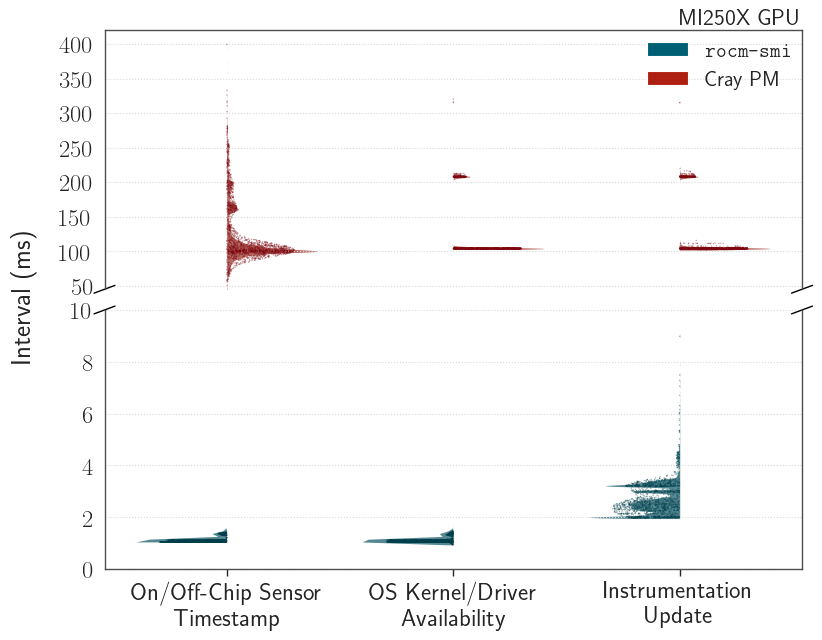

Saved plot to mi250x_dist_density_filled.png


/tmp/ipykernel_1804609/973444561.py:101: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_1804609/973444561.py:101: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


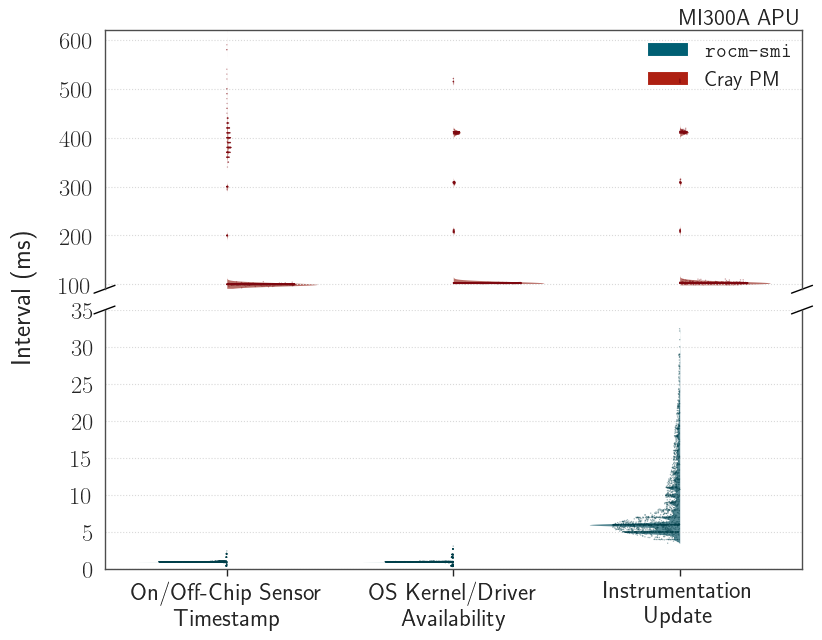

Saved plot to mi300a_dist_density_filled.png


In [21]:
def plot_interval_distribution_density_scatter(
    instrumentation_timestamp_csv: str,
    sensor_timestamp_csv: str,
    output_plot: str,
    title: str = "Update Interval Distributions (MI250X)",
    break_start: float = 10.0,  
    break_end: float = 50.0,    
    y_max_top: float = None,
    low_base: int = 2,
    high_base: int = 50,
):
    sns.set_context("paper", font_scale=2.0)
    sns.set_style("whitegrid", {
        "axes.grid": True, 
        "grid.linestyle": ":", 
        "grid.color": "0.85",
        "axes.edgecolor": "0.3"
    })
    
    plt.rcParams.update({
        "text.usetex": True,
    })

    # Load data
    instr_df = pd.DataFrame()
    sensor_df = pd.DataFrame()

    if os.path.exists(instrumentation_timestamp_csv):
        try: instr_df = pd.read_csv(instrumentation_timestamp_csv)
        except: pass

    if os.path.exists(sensor_timestamp_csv):
        try: sensor_df = pd.read_csv(sensor_timestamp_csv)
        except: pass

    # Define data sources
    label_rocm = r'$\texttt{rocm-smi}$'
    label_cray = r'Cray PM'

    mappings = [
        (sensor_df, 'dt_rocm_timestamp (ms)',    'On/Off-Chip Sensor\nTimestamp', label_rocm),
        (sensor_df, 'dt_cray_timestamp (ms)',    'On/Off-Chip Sensor\nTimestamp', label_cray),
        (sensor_df, 'dt_rocm_availability (ms)', 'OS Kernel/Driver\nAvailability', label_rocm),
        (sensor_df, 'dt_cray_availability (ms)', 'OS Kernel/Driver\nAvailability', label_cray),
        (instr_df,  'ROCm Time Between Instrumentation Readings (ms)',   'Instrumentation\nUpdate', label_rocm),
        (instr_df,  'CrayPM Time Between Instrumentation Readings (ms)', 'Instrumentation\nUpdate', label_cray),
    ]

    # Consolidate data into a downsampled DataFrame for plotting
    violin_records = []
    scatter_records = []
    rng = np.random.default_rng(42) 

    MAX_VIOLIN_POINTS = 5000
    MAX_SCATTER_POINTS = 2000 # Enough to look "full" but not messy

    for df, col_name, metric_type, source in mappings:
        if df.empty or col_name not in df.columns: continue
        
        data = df[col_name].to_numpy()
        data = data[np.isfinite(data)]
        data = data[data > 0]
        
        if data.size == 0: continue

        # Sample for Violin
        v_data = data
        if len(data) > MAX_VIOLIN_POINTS:
            v_data = rng.choice(data, MAX_VIOLIN_POINTS, replace=False)
        
        # Sample for Scatter
        s_data = v_data
        if len(v_data) > MAX_SCATTER_POINTS:
            s_data = rng.choice(v_data, MAX_SCATTER_POINTS, replace=False)

        for val in v_data:
            violin_records.append({"Interval (ms)": val, "Metric": metric_type, "Source": source})
        for val in s_data:
            scatter_records.append({"Interval (ms)": val, "Metric": metric_type, "Source": source})

    if not violin_records:
        print("Error: No valid data found to plot.")
        return

    df_violin = pd.DataFrame(violin_records)
    df_scatter = pd.DataFrame(scatter_records)

    # Setup broken axis plot
    f, (ax_top, ax_bottom) = plt.subplots(2, 1, sharex=True, figsize=(9, 7), 
                                          gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.08})
    
    color_rocm = '#005f73' # Deep Teal
    color_cray = '#ae2012' # Rust Red
    palette = {label_rocm: color_rocm, label_cray: color_cray}
    hue_order = [label_rocm, label_cray]
    order = ['On/Off-Chip Sensor\nTimestamp', 'OS Kernel/Driver\nAvailability', 'Instrumentation\nUpdate']

    # Violin + density-filled scatter function
    def plot_on_axis(ax):
        # Split violin
        sns.violinplot(
            data=df_violin, x='Metric', y='Interval (ms)', hue='Source',
            palette=palette, order=order, hue_order=hue_order,
            split=True,         
            inner=None,         
            scale='width',      
            density_norm='width',
            linewidth=0,        
            cut=0,              
            gridsize=1000,      
            bw_adjust=0.2,      
            ax=ax,
            alpha=0.7,
            zorder=0
        )
        
        # This manually places dots to match the violin shape perfectly
        
        metric_map = {m: i for i, m in enumerate(order)}
        width_scale = 0.3 # Controls how "wide" the scatter cloud is (match violin width)

        for metric in order:
            for source in hue_order:
                # Get data subset
                subset = df_scatter[(df_scatter['Metric'] == metric) & (df_scatter['Source'] == source)]
                if subset.empty: continue
                
                y_vals = subset['Interval (ms)'].values
                
                # Add tiny noise to prevent singular matrix error on KDE if all values are identical
                y_noise = y_vals + rng.normal(0, 0.001, size=len(y_vals))
                
                # Calculate KDE Density for each point
                try:
                    kde = gaussian_kde(y_noise, bw_method=0.2)
                    density = kde(y_vals)
                    # Normalize density 0-1
                    density = density / density.max()
                except:
                    # Fallback if KDE fails (e.g. single point)
                    density = np.ones(len(y_vals))

                # Calculate X coordinates
                base_x = metric_map[metric]
                
                # Generate jitter proportional to density
                # This makes the cloud wide where the violin is wide
                jitter = rng.uniform(0, density * width_scale)
                
                # Assign to Left or Right side
                if source == label_rocm:
                    x_vals = base_x - jitter
                    color = '#003f4a'
                else:
                    x_vals = base_x + jitter
                    color = '#7e070f'
                
                # Plot
                ax.scatter(
                    x_vals, y_vals, 
                    s=1,
                    color=color, 
                    alpha=0.4, 
                    edgecolors='none', 
                    zorder=10
                )

        ax.grid(axis='x', visible=False) 
        ax.yaxis.set_major_locator(ticker.MultipleLocator(base=high_base if ax == ax_top else low_base))
        if ax.get_legend() is not None: ax.get_legend().remove()

    # Render plots on both axes
    plot_on_axis(ax_top)
    plot_on_axis(ax_bottom)

    # Configure range
    ax_top.set_ylim(bottom=break_end) 
    if y_max_top: ax_top.set_ylim(top=y_max_top)
    ax_bottom.set_ylim(0, break_start)

    # Stylize the break in the graph
    ax_top.spines['bottom'].set_visible(False)
    ax_bottom.spines['top'].set_visible(False)
    ax_top.tick_params(labeltop=False)  
    ax_bottom.xaxis.tick_bottom()

    d = .015 
    kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False, linewidth=1)
    ax_top.plot((-d, +d), (-d, +d), **kwargs)        
    ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)  
    kwargs.update(transform=ax_bottom.transAxes) 
    ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)  
    ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs) 

    # Labels
    ax_top.set_xlabel("")
    ax_bottom.set_xlabel("")
    ax_bottom.set_ylabel("") 
    ax_top.set_ylabel("")    
    f.text(0.02, 0.5, 'Interval (ms)', va='center', rotation='vertical', weight='bold')

    legend_elements = [
        Patch(facecolor=color_rocm, edgecolor=None, label=label_rocm, alpha=1.0),
        Patch(facecolor=color_cray, edgecolor=None, label=label_cray, alpha=1.0)
    ]
    # ax_top.legend(handles=legend_elements, loc='upper left', title=title, borderpad=0.0001, frameon=False, fontsize=15, title_fontsize=16, framealpha=0.95, bbox_to_anchor=(1.0, 1.0))

    ax_top.legend(handles=legend_elements, loc='upper right',  borderpad=0.05, fontsize=15, title_fontsize=16, frameon=False, framealpha=0.95)

    # Now show a small note above the top right of the plot: mi250x or mi300a
    f.text(0.9, 0.91, title, ha='right', va='top', fontsize=16, weight='bold')

    clean_filename = output_plot.replace(".png", "") + "_density_filled.png"
    plt.savefig(clean_filename, dpi=600, bbox_inches='tight')
    plt.show()
    print(f"Saved plot to {clean_filename}")

plot_interval_distribution_density_scatter(
    instrumentation_timestamp_csv='update-interval-data/dt_scorep_instrumentation_wallclock_mi250x.csv',
    sensor_timestamp_csv='/lustre/orion/csc688/world-shared/data_energy_sampling_128_nodes/dt_timestamps_mi250x.csv',
    output_plot='mi250x_dist.png',
    title="MI250X GPU",
    break_start=10.0,  
    break_end=45.0,
    y_max_top=420.0
)

plot_interval_distribution_density_scatter(
    instrumentation_timestamp_csv='update-interval-data/dt_scorep_instrumentation_wallclock_mi300a.csv',
    sensor_timestamp_csv='/lustre/orion/csc688/world-shared/data_energy_sampling_128_nodes/dt_timestamps_mi300a.csv',
    output_plot='mi300a_dist.png',
    title="MI300A APU",
    low_base=5,
    high_base=100,
    break_start=35.0,  
    break_end=90.0,
    y_max_top=620.0
)

In [22]:
# Get the end time of the notebook
NOTEBOOK_END_TIME = time.time()
print(f"Notebook end time: {NOTEBOOK_END_TIME}")
print(f"Notebook end at {NOTEBOOK_END_TIME} ({datetime.datetime.fromtimestamp(NOTEBOOK_END_TIME)})")

NOTEBOOK_DURATION = NOTEBOOK_END_TIME - NOTEBOOK_START_TIME
print(f"Notebook execution time: {NOTEBOOK_DURATION:.2f} seconds")

Notebook end time: 1766156758.9316878
Notebook end at 1766156758.9316878 (2025-12-19 10:05:58.931688)
Notebook execution time: 307.31 seconds
